# Практическое задание 2

Статистическая проверка критериев по данным UN Tourism.

In [ ]:
!pip install pandas numpy scipy openpyxl matplotlib

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = Path('.')
DATA = BASE / 'data'
DATA.mkdir(exist_ok=True)
ASSETS = BASE / 'assets'
ASSETS.mkdir(exist_ok=True)

ARR_FILE = DATA / 'UN_Tourism_inbound_arrivals_12_2025.xlsx'
EXP_FILE = DATA / 'UN_Tourism_inbound_expenditure_12_2025.xlsx'

MAP_RU_EN = {
    'Австрия':'Austria',
    'Албания':'Albania',
    'Андорра':'Andorra',
    'Армения':'Armenia',
    'Беларусь':'Belarus',
    'Бельгия':'Belgium',
    'Болгария':'Bulgaria',
    'Босния и Герцеговина':'Bosnia and Herzegovina',
    'Великобритания':'United Kingdom of Great Britain and Northern Ireland',
    'Венгрия':'Hungary',
    'Германия':'Germany',
    'Греция':'Greece',
    'Грузия':'Georgia',
    'Дания':'Denmark',
    'Исландия':'Iceland',
    'Испания':'Spain',
    'Италия':'Italy',
    'Кипр':'Cyprus',
    'Латвия':'Latvia',
    'Литва':'Lithuania',
    'Люксембург':'Luxembourg',
    'Мальта':'Malta',
    'Молдова':'Republic of Moldova',
    'Нидерланды':'Netherlands (Kingdom of the)',
    'Норвегия':'Norway',
    'Польша':'Poland',
    'Португалия':'Portugal',
    'Румыния':'Romania',
    'Сан-Марино':'San Marino',
    'Северная Македония':'North Macedonia',
    'Сербия':'Serbia',
    'Словения':'Slovenia',
    'Турция':'Türkiye',
    'Украина':'Ukraine',
    'Франция':'France',
    'Хорватия':'Croatia',
    'Черногория':'Montenegro',
    'Чехия':'Czechia',
    'Швейцария':'Switzerland',
    'Швеция':'Sweden',
    'Эстония':'Estonia',
}

arr = pd.read_excel(ARR_FILE, sheet_name='Data')
exp = pd.read_excel(EXP_FILE, sheet_name='Data')

arr = arr[(arr['indicator_label'] == 'inbound - trips - total - total - overnight visitors (tourists)') & (arr['year'].isin([2019, 2021]))]
exp = exp[(exp['indicator_label'] == 'inbound - expenditure - balance of payments - total - visitors') & (exp['year'].isin([2019, 2021]))]

rows = []
for ru, en in MAP_RU_EN.items():
    for year in [2019, 2021]:
        a = arr[(arr['reporter_area_label'] == en) & (arr['year'] == year)]['value']
        e = exp[(exp['reporter_area_label'] == en) & (exp['year'] == year)]['value']
        rows.append({
            'Страна': ru,
            'Год': year,
            'Прибытия, тыс.': float(a.iloc[0]) if len(a) else np.nan,
            'Поступления, млн USD': float(e.iloc[0]) if len(e) else np.nan,
        })

df = pd.DataFrame(rows)
df['Receipts per Arrival, USD'] = df['Поступления, млн USD'] / df['Прибытия, тыс.'] * 1000

main_2021 = df[(df['Год'] == 2021) & df['Receipts per Arrival, USD'].notna()].copy().sort_values('Страна').reset_index(drop=True)
main_2019 = df[(df['Год'] == 2019) & df['Receipts per Arrival, USD'].notna()].copy().sort_values('Страна').reset_index(drop=True)

paired = main_2019[['Страна', 'Receipts per Arrival, USD']].merge(
    main_2021[['Страна', 'Receipts per Arrival, USD']],
    on='Страна', suffixes=('_2019', '_2021')
)
paired['Изменение, USD'] = paired['Receipts per Arrival, USD_2021'] - paired['Receipts per Arrival, USD_2019']

print(f'Наблюдений за 2021 год: {len(main_2021)}')
print(f'Парных наблюдений 2019/2021: {len(paired)}')
main_2021.head()

Наблюдений за 2021 год: 41
Парных наблюдений 2019/2021: 31


,Страна,Год,"Прибытия, тыс.","Поступления, млн USD","Receipts per Arrival, USD"
0,Австрия,2021,12728.0,11944.468544,938.440332
1,Албания,2021,5515.0,2479.950546,449.673716
2,Андорра,2021,1949.0,1924.879674,987.624255
3,Армения,2021,876.0,813.427196,928.569859
4,Беларусь,2021,787.0,661.529396,840.571025


## 1. Формирование дополнительных выборок

Для критерия Манна-Уитни берутся две контрастные группы стран:
- нижний квартиль по прибытиям;
- верхний квартиль по прибытиям.

Для критерия Уилкоксона строится парная выборка из стран, для которых показатель рассчитан и за 2019, и за 2021 год.


In [2]:
q1_arrivals = main_2021['Прибытия, тыс.'].quantile(0.25)
q3_arrivals = main_2021['Прибытия, тыс.'].quantile(0.75)

low_group = main_2021[main_2021['Прибытия, тыс.'] <= q1_arrivals].copy().sort_values('Receipts per Arrival, USD', ascending=False)
high_group = main_2021[main_2021['Прибытия, тыс.'] >= q3_arrivals].copy().sort_values('Receipts per Arrival, USD', ascending=False)

print('Q1 по прибытиям:', q1_arrivals)
print('Q3 по прибытиям:', q3_arrivals)
print('Размеры групп:', len(low_group), len(high_group))

low_group[['Страна', 'Прибытия, тыс.', 'Receipts per Arrival, USD']].head()

Q1 по прибытиям: 876.0
Q3 по прибытиям: 7929.1
Размеры групп: 11 11


,Страна,"Прибытия, тыс.","Receipts per Arrival, USD"
20,Люксембург,615.000,9869.002403
22,Молдова,68.852,7030.587347
30,Сербия,871.000,2501.902630
28,Сан-Марино,94.000,2391.058380
7,Босния и Герцеговина,502.000,2113.978669


## 2. Проверка критериев

Используются четыре критерия:
1. Шапиро-Уилка - для проверки нормальности распределения показателя за 2021 год.
2. Спирмена - для оценки связи между прибытием туристов и поступлениями.
3. Манна-Уитни - для сравнения крайних групп стран по потоку туристов.
4. Уилкоксона - для парного сравнения показателя в 2019 и 2021 годах.


In [3]:
rpa_2021 = main_2021['Receipts per Arrival, USD']
arrivals_2021 = main_2021['Прибытия, тыс.']
exp_2021 = main_2021['Поступления, млн USD']

shapiro_w, shapiro_p = stats.shapiro(rpa_2021)
spearman_rho, spearman_p = stats.spearmanr(arrivals_2021, exp_2021, alternative='two-sided')
mw_u, mw_p = stats.mannwhitneyu(
    low_group['Receipts per Arrival, USD'],
    high_group['Receipts per Arrival, USD'],
    alternative='two-sided',
    method='asymptotic'
)
wilcoxon_w, wilcoxon_p = stats.wilcoxon(
    paired['Receipts per Arrival, USD_2021'],
    paired['Receipts per Arrival, USD_2019'],
    alternative='greater',
    zero_method='wilcox',
    correction=False,
    method='auto'
)

results = pd.DataFrame({
    'Критерий': ['Шапиро-Уилка', 'Спирмена', 'Манна-Уитни', 'Уилкоксона'],
    'Статистика': [shapiro_w, spearman_rho, mw_u, wilcoxon_w],
    'p-value': [shapiro_p, spearman_p, mw_p, wilcoxon_p]
})
results

,Критерий,Статистика,p-value
0,Шапиро-Уилка,0.626911,5.592000e-09
1,Спирмена,0.871254,1.278061e-13
2,Манна-Уитни,95.000000,2.557465e-02
3,Уилкоксона,496.000000,4.656613e-10


In [ ]:
log_rpa_2021 = np.log(rpa_2021)
shapiro_log_w, shapiro_log_p = stats.shapiro(log_rpa_2021)
kendall_tau, kendall_p = stats.kendalltau(arrivals_2021, exp_2021, alternative='two-sided')
sign_res = stats.binomtest((paired['Изменение, USD'] > 0).sum(),
                           n=(paired['Изменение, USD'] != 0).sum(),
                           p=0.5, alternative='greater')

extra_results = pd.DataFrame({
    'Критерий': ['Шапиро-Уилка для log(RPA)', 'Кендалла', 'Точный критерий знаков'],
    'Статистика': [shapiro_log_w, kendall_tau, sign_res.k],
    'p-value': [shapiro_log_p, kendall_p, sign_res.pvalue]
})
extra_results

## 3. Диаграммы для отчета

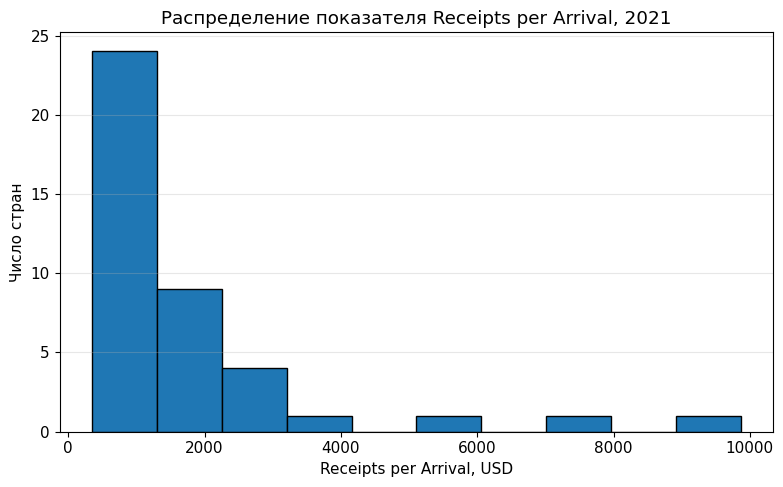

In [4]:
plt.rcParams.update({'font.size': 11})

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(rpa_2021, bins=10, edgecolor='black')
ax.set_xlabel('Receipts per Arrival, USD')
ax.set_ylabel('Число стран')
ax.set_title('Распределение показателя Receipts per Arrival, 2021')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'hist_rpa_2021.png', dpi=200)
plt.show()

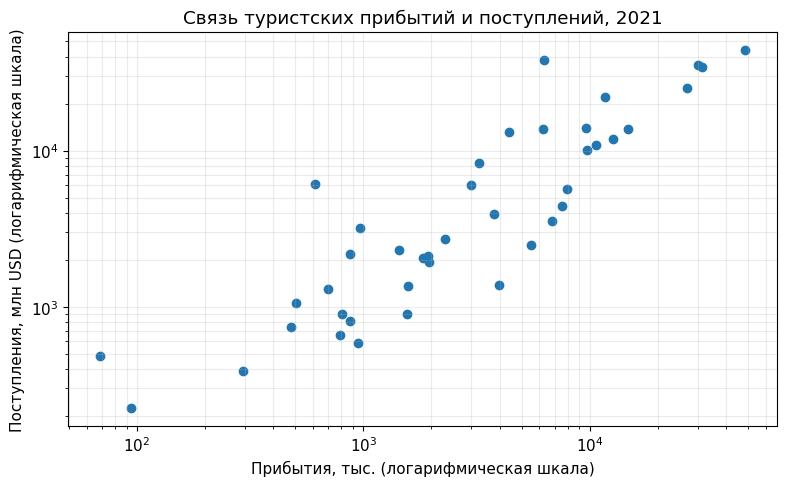

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(arrivals_2021, exp_2021)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Прибытия, тыс. (логарифмическая шкала)')
ax.set_ylabel('Поступления, млн USD (логарифмическая шкала)')
ax.set_title('Связь туристских прибытий и поступлений, 2021')
ax.grid(True, which='both', alpha=0.25)
fig.tight_layout()
fig.savefig(ASSETS / 'scatter_arrivals_expenditure.png', dpi=200)
plt.show()

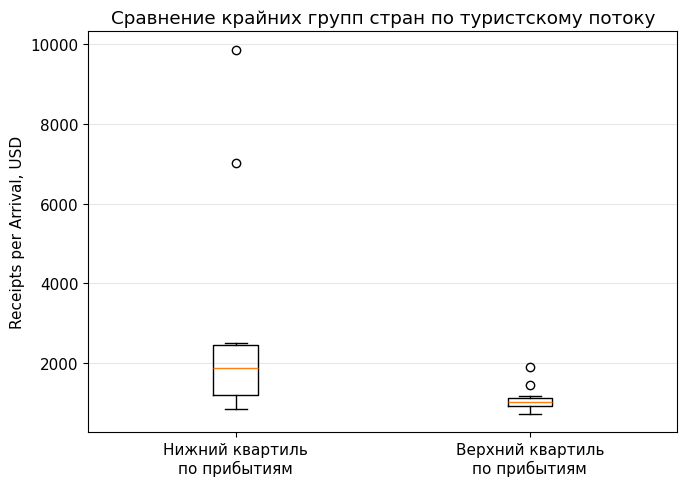

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([
    low_group['Receipts per Arrival, USD'],
    high_group['Receipts per Arrival, USD']
], tick_labels=['Нижний квартиль\nпо прибытиям', 'Верхний квартиль\nпо прибытиям'])
ax.set_ylabel('Receipts per Arrival, USD')
ax.set_title('Сравнение крайних групп стран по туристскому потоку')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'boxplot_flow_groups.png', dpi=200)
plt.show()

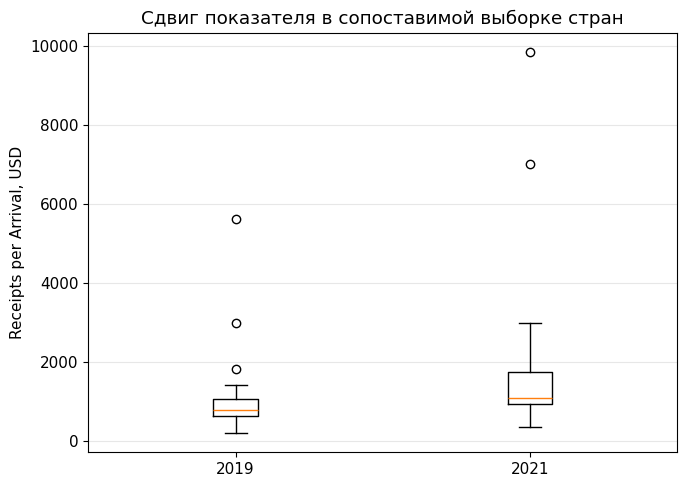

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([
    paired['Receipts per Arrival, USD_2019'],
    paired['Receipts per Arrival, USD_2021']
], tick_labels=['2019', '2021'])
ax.set_ylabel('Receipts per Arrival, USD')
ax.set_title('Сдвиг показателя в сопоставимой выборке стран')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'paired_boxplot_2019_2021.png', dpi=200)
plt.show()